<strong><center><h1> Spectral Clustering </h1></center></strong>

In [1]:
import pandas as pd
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

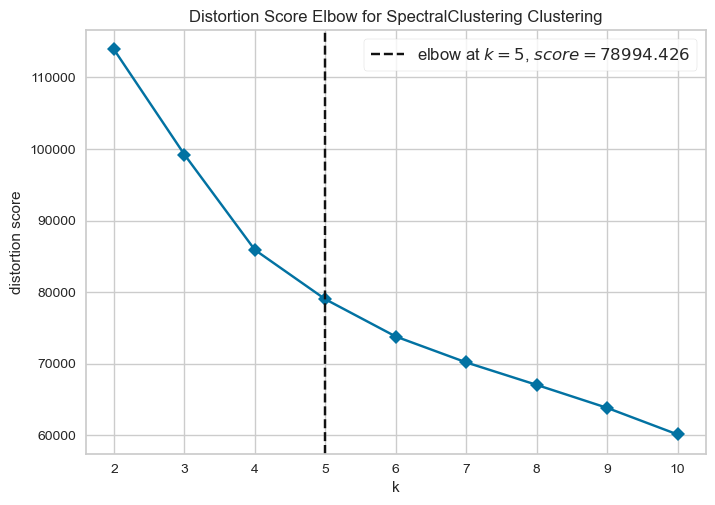

In [3]:
data_path = '../../../../data/processed_data/main_datasets/customer_data_processed.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = SpectralClustering(affinity='nearest_neighbors', random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 11), timings=False)
visualizer.fit(X_scaled)
visualizer.show();

In [4]:
n_clusters = visualizer.elbow_value_

spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
data['Cluster'] = spectral.fit_predict(X_scaled)

In [5]:
output_path = '../../../../data/processed_data/train_models_data/data_without_PCA/data_without_generated_features/SpectralClustering_default.csv'
data.to_csv(output_path, index=False)